In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/reubensuju/celeb-df-v2/List_of_testing_videos.txt
/kaggle/input/datasets/reubensuju/celeb-df-v2/YouTube-real/00238.mp4
/kaggle/input/datasets/reubensuju/celeb-df-v2/YouTube-real/00152.mp4
/kaggle/input/datasets/reubensuju/celeb-df-v2/YouTube-real/00269.mp4
/kaggle/input/datasets/reubensuju/celeb-df-v2/YouTube-real/00209.mp4
/kaggle/input/datasets/reubensuju/celeb-df-v2/YouTube-real/00297.mp4
/kaggle/input/datasets/reubensuju/celeb-df-v2/YouTube-real/00096.mp4
/kaggle/input/datasets/reubensuju/celeb-df-v2/YouTube-real/00255.mp4
/kaggle/input/datasets/reubensuju/celeb-df-v2/YouTube-real/00230.mp4
/kaggle/input/datasets/reubensuju/celeb-df-v2/YouTube-real/00259.mp4
/kaggle/input/datasets/reubensuju/celeb-df-v2/YouTube-real/00012.mp4
/kaggle/input/datasets/reubensuju/celeb-df-v2/YouTube-real/00219.mp4
/kaggle/input/datasets/reubensuju/celeb-df-v2/YouTube-real/00003.mp4
/kaggle/input/datasets/reubensuju/celeb-df-v2/YouTube-real/00147.mp4
/kaggle/input/datasets/reubens

In [2]:
# ============================================================
# ENVIRONMENT SETUP — run this first, every session
# --no-deps is deliberate: prevents facenet-pytorch from pulling in a
# different numpy/torch/torchvision/Pillow than what Kaggle already has
# installed together (and already mutually compatible). Letting pip'''s
# resolver touch those is what caused the numpy ABI corruption and the
# Pillow/torchvision conflict in earlier attempts.
# ============================================================
!pip install -q --no-deps facenet-pytorch==2.6.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 25.0 MB/s eta 0:00:00


In [3]:
# ============================================================
# PATCH: restore is_directory/is_path to PIL._util BEFORE importing
# torchvision. Newer Pillow (needed by facenet-pytorch) removed these,
# which breaks torchvision's ImageFont import chain. This is not
# fixable by picking a Pillow/torchvision version — no compatible pair
# exists — so we patch the two missing functions back in directly.
# ============================================================
import os
import PIL._util as _util

if not hasattr(_util, "is_directory"):
    _util.is_directory = lambda path: os.path.isdir(path)
if not hasattr(_util, "is_path"):
    _util.is_path = lambda path: isinstance(path, (bytes, str, os.PathLike))

import torch, torchvision, PIL
import importlib.metadata

print("Torch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("Pillow:", PIL.__version__)
print("facenet-pytorch:", importlib.metadata.version("facenet-pytorch"))
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

from facenet_pytorch import MTCNN
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
_test_mtcnn = MTCNN(keep_all=True, device=device)
print("facenet-pytorch import + MTCNN init: OK")


Torch: 2.10.0+cu128
Torchvision: 0.25.0+cu128
Pillow: 11.3.0
facenet-pytorch: 2.6.0
CUDA available: True
GPU: Tesla T4
facenet-pytorch import + MTCNN init: OK


In [4]:
# ============================================================
# LOAD SHARED PROJECT UTILITIES
# ============================================================
import os, sys

REPO_URL = "https://github.com/Mugdha-Naik/deepfake-detector-project.git"
REPO_DIR = "/kaggle/working/repo"

if not os.path.exists(REPO_DIR):
    os.system(f"git clone {REPO_URL} {REPO_DIR}")
else:
    os.system(f"cd {REPO_DIR} && git pull")

sys.path.append(REPO_DIR)

from utils import (
    get_kaggle_video_path, verify_path_resolution, get_label_from_path,
    load_mtcnn, extract_faces_from_video, apply_quality_filters,
    CELEB_ROOT, FF_ROOT, CSV_URL,
)

print("utils.py loaded successfully")


Cloning into '/kaggle/working/repo'...


utils.py loaded successfully


In [5]:
import cv2
import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

print("Celeb-DF exists:", os.path.exists(CELEB_ROOT))
print("FF++ exists:", os.path.exists(FF_ROOT))


Celeb-DF exists: True
FF++ exists: True


In [6]:
df = pd.read_csv(CSV_URL)
df["kaggle_path"] = df["video_path"].apply(get_kaggle_video_path)
df["label_name"] = df["video_path"].apply(get_label_from_path)

print("Total videos:", len(df))
print("Class distribution:")
print(df["label_name"].value_counts(dropna=False))


Total videos: 13529
Class distribution:
label_name
FAKE    11639
REAL     1890
Name: count, dtype: int64


In [7]:
# ============================================================
# VERIFY: check both REAL and FAKE paths resolve correctly
# ============================================================
verify_path_resolution(df)


data/raw\cel\Celeb-real\id0_0000.mp4 -> /kaggle/input/datasets/reubensuju/celeb-df-v2/Celeb-real/id0_0000.mp4 | exists: True
data/raw\cel\Celeb-real\id0_0001.mp4 -> /kaggle/input/datasets/reubensuju/celeb-df-v2/Celeb-real/id0_0001.mp4 | exists: True
data/raw\FaceForensics++_C23\DeepFakeDetection\01_02__meeting_serious__YVGY8LOK.mp4 -> /kaggle/input/datasets/xdxd003/ff-c23/FaceForensics++_C23/DeepFakeDetection/01_02__meeting_serious__YVGY8LOK.mp4 | exists: True
data/raw\FaceForensics++_C23\DeepFakeDetection\01_02__outside_talking_still_laughing__YVGY8LOK.mp4 -> /kaggle/input/datasets/xdxd003/ff-c23/FaceForensics++_C23/DeepFakeDetection/01_02__outside_talking_still_laughing__YVGY8LOK.mp4 | exists: True


In [8]:
# ============================================================
# BUILD A BALANCED REAL/FAKE SAMPLE
# Increase NUM_REAL / NUM_FAKE once the small batch is verified working.
# ============================================================
NUM_REAL = 10
NUM_FAKE = 10

real_df = df[df["label_name"] == "REAL"].copy()
fake_df = df[df["label_name"] == "FAKE"].copy()

print("Available REAL videos:", len(real_df))
print("Available FAKE videos:", len(fake_df))

test_real = real_df.sample(n=min(NUM_REAL, len(real_df)), random_state=42)
test_fake = fake_df.sample(n=min(NUM_FAKE, len(fake_df)), random_state=42)

run_df = pd.concat([test_real, test_fake], ignore_index=True)
run_df = run_df.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nTotal videos selected:", len(run_df))
print(run_df["label_name"].value_counts())


Available REAL videos: 1890
Available FAKE videos: 11639

Total videos selected: 20
label_name
REAL    10
FAKE    10
Name: count, dtype: int64


In [9]:
mtcnn, device = load_mtcnn()


MTCNN loaded. Device: cuda


In [10]:
OUTPUT_DIR = "/kaggle/working/step5_faces"
FACES_DIR = os.path.join(OUTPUT_DIR, "faces")
os.makedirs(FACES_DIR, exist_ok=True)
print("Faces directory:", FACES_DIR)


Faces directory: /kaggle/working/step5_faces/faces


In [11]:
# ============================================================
# MAIN EXTRACTION LOOP (balanced, labeled)
# sampling="interval" matches Step 4's convention.
# ============================================================
all_records = []

for idx, row in tqdm(run_df.iterrows(), total=len(run_df), desc="Step 5 extraction"):
    video_path = row["kaggle_path"]
    label_name = row["label_name"]

    if not video_path or not os.path.exists(video_path):
        print("Video not found:", row["video_path"])
        continue

    video_id = f"video_{idx}"

    records = extract_faces_from_video(
        video_path=video_path,
        label_name=label_name,
        faces_dir=FACES_DIR,
        video_id=video_id,
        mtcnn=mtcnn,
        sampling="interval",
    )
    all_records.extend(records)

step5_df = pd.DataFrame(all_records)

print("=" * 60)
print("EXTRACTION COMPLETE")
print("Face crops:", len(step5_df))
print(step5_df["label_name"].value_counts())


Step 5 extraction:   0%|          | 0/20 [00:00<?, ?it/s]

EXTRACTION COMPLETE
Face crops: 1011
label_name
REAL    536
FAKE    475
Name: count, dtype: int64


Total face crops found: 1011
Showing 6 REAL and 6 FAKE samples


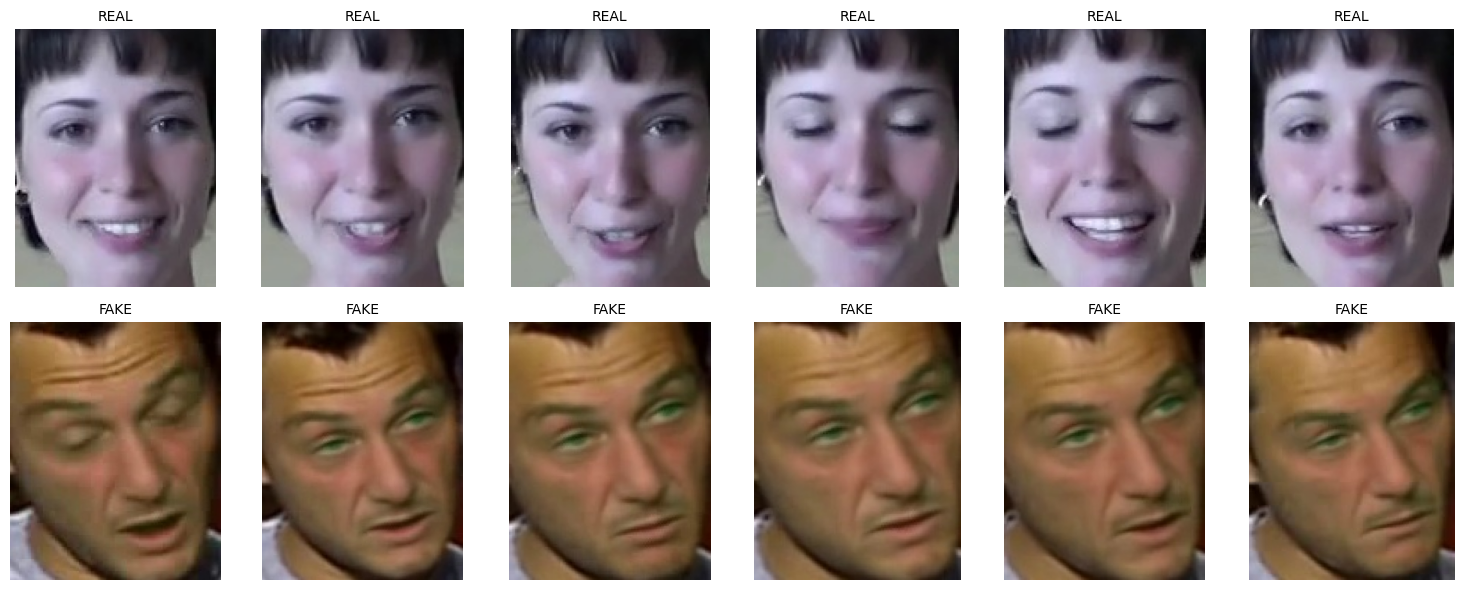

In [12]:
# ============================================================
# SANITY CHECK — view a sample of saved face crops (both classes)
# ============================================================
import matplotlib.pyplot as plt
from PIL import Image

real_samples = step5_df[step5_df["label_name"] == "REAL"]["face_path"].head(6).tolist()
fake_samples = step5_df[step5_df["label_name"] == "FAKE"]["face_path"].head(6).tolist()
sample_paths = real_samples + fake_samples

print("Total face crops found:", len(step5_df))
print("Showing", len(real_samples), "REAL and", len(fake_samples), "FAKE samples")

plt.figure(figsize=(15, 6))
for i, image_path in enumerate(sample_paths):
    image = Image.open(image_path)
    plt.subplot(2, 6, i + 1)
    plt.imshow(image)
    plt.axis("off")
    label = "REAL" if i < len(real_samples) else "FAKE"
    plt.title(label, fontsize=10)
plt.tight_layout()
plt.show()


In [13]:
# ============================================================
# QUALITY FILTERING — blur + size (via utils.apply_quality_filters)
# ============================================================
step5_df, quality_filtered_df = apply_quality_filters(step5_df)

total_in = len(step5_df)
dropped_blur = (~step5_df["blur_pass"]).sum()
dropped_size = (step5_df["blur_pass"] & ~step5_df["size_pass"]).sum()
remaining = step5_df["quality_pass"].sum()

print("=" * 60)
print("QUALITY FILTERING RESULT")
print("=" * 60)
print("Total faces in:", total_in)
print("Dropped due to blur:", dropped_blur)
print("Dropped due to size:", dropped_size)
print("Remaining:", remaining)
print(f"Percentage dropped: {round((total_in - remaining) / total_in * 100, 2)}%")


QUALITY FILTERING RESULT
Total faces in: 1011
Dropped due to blur: 614
Dropped due to size: 0
Remaining: 397
Percentage dropped: 60.73%


In [14]:
# ============================================================
# PER-CLASS SUMMARY
# ============================================================
class_summary = []

for label in ["REAL", "FAKE"]:
    class_df = step5_df[step5_df["label_name"] == label]
    class_filtered = quality_filtered_df[quality_filtered_df["label_name"] == label]

    class_total = len(class_df)
    class_remaining = len(class_filtered)
    class_blur_drop = (~class_df["blur_pass"]).sum()
    class_size_drop = (class_df["blur_pass"] & ~class_df["size_pass"]).sum()

    class_summary.append({
        "class": label,
        "total_in": class_total,
        "dropped_blur": int(class_blur_drop),
        "dropped_size": int(class_size_drop),
        "remaining": class_remaining,
        "drop_percentage": round((class_total - class_remaining) / class_total * 100, 2) if class_total else 0
    })

class_summary_df = pd.DataFrame(class_summary)
class_summary_df


,class,total_in,dropped_blur,dropped_size,remaining,drop_percentage
0,REAL,536,158,0,378,29.48
1,FAKE,475,456,0,19,96.00


In [15]:
# ============================================================
# SAVE FINAL OUTPUTS
# ============================================================
STEP5_DIR = "/kaggle/working/step5_quality"
os.makedirs(STEP5_DIR, exist_ok=True)

FILTERED_PATH = os.path.join(STEP5_DIR, "quality_filtered_faces.csv")
quality_filtered_df.to_csv(FILTERED_PATH, index=False)

CLASS_SUMMARY_PATH = os.path.join(STEP5_DIR, "step5_class_summary.csv")
class_summary_df.to_csv(CLASS_SUMMARY_PATH, index=False)

overall_summary = pd.DataFrame([{
    "total_faces_in": total_in,
    "dropped_blur": int(dropped_blur),
    "dropped_size": int(dropped_size),
    "remaining": int(remaining),
    "percentage_dropped": round((total_in - remaining) / total_in * 100, 2)
}])
OVERALL_SUMMARY_PATH = os.path.join(STEP5_DIR, "step5_overall_summary.csv")
overall_summary.to_csv(OVERALL_SUMMARY_PATH, index=False)

print("Saved:")
print(" ", FILTERED_PATH)
print(" ", CLASS_SUMMARY_PATH)
print(" ", OVERALL_SUMMARY_PATH)


Saved:
  /kaggle/working/step5_quality/quality_filtered_faces.csv
  /kaggle/working/step5_quality/step5_class_summary.csv
  /kaggle/working/step5_quality/step5_overall_summary.csv


In [16]:
print("=" * 60)
print("STEP 5 FINAL CHECK")
print("=" * 60)
print("Final face count:", len(quality_filtered_df))
print("\nFinal REAL/FAKE distribution:")
print(quality_filtered_df["label_name"].value_counts())


STEP 5 FINAL CHECK
Final face count: 397

Final REAL/FAKE distribution:
label_name
REAL    378
FAKE     19
Name: count, dtype: int64
